In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

In [2]:
nav_df = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

perf_df = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

benchmark_df = pd.read_csv(
    "../data/processed/clean_benchmark_indices.csv"
)

fund_df = pd.read_csv(
    "../data/processed/clean_fund_master.csv"
)

nav_df["date"] = pd.to_datetime(
    nav_df["date"]
)

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

# Daily Returns

In [3]:
nav_df = nav_df.sort_values(
    ["amfi_code","date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

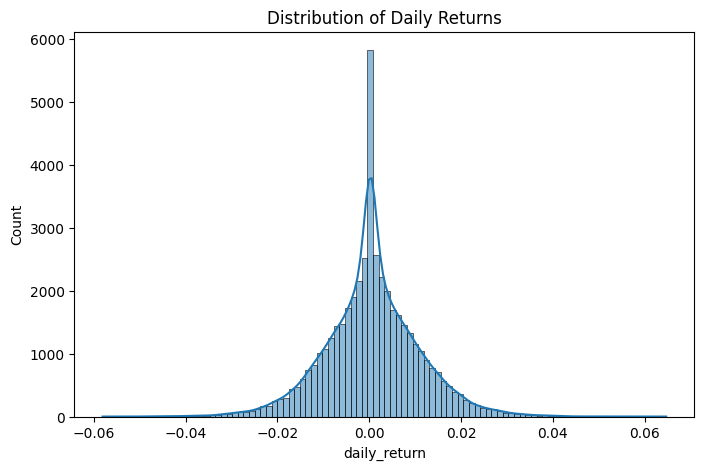

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title(
    "Distribution of Daily Returns"
)

plt.show()

In [5]:
def calculate_cagr(start_nav,end_nav,years):

    return (
        (end_nav/start_nav)
        **(1/years)
        -1
    )

# CAGR

In [6]:
cagr_results = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ]

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


# Sharpe Ratio

In [7]:
risk_free_rate = 0.065

sharpe_results = []

for fund in nav_df["amfi_code"].unique():

    returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    annual_return = (
        returns.mean()*252
    )

    annual_std = (
        returns.std()*np.sqrt(252)
    )

    sharpe = (
        annual_return
        -
        risk_free_rate
    ) / annual_std

    sharpe_results.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


# Sortino Ratio

In [8]:
sortino_results = []

for fund in nav_df["amfi_code"].unique():

    returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()
        *252
    )

    sortino = (
        annual_return
        -
        risk_free_rate
    ) / downside_std

    sortino_results.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [9]:
print(benchmark_df.columns.tolist())
print(benchmark_df.head())

['date', 'index_name', 'close_value']
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


# Alpha & Beta

First calculate benchmark returns.

In [10]:
benchmark_df = benchmark_df.sort_values(
    ["index_name", "date"]
)

benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")
    ["close_value"]
    .pct_change()
)

In [11]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
][["date","benchmark_return"]]

In [12]:
alpha_beta_results = []

for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 50:

        slope, intercept, r, p, std = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope

        alpha = intercept * 252

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


# Maximum Drawdown

In [13]:
mdd_results = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        -1
    )

    mdd = temp["drawdown"].min()

    mdd_results.append(
        [fund,mdd]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [14]:
mdd_results = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        -1
    )

    mdd = temp["drawdown"].min()

    mdd_results.append(
        [fund,mdd]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [15]:
mdd_results = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        -1
    )

    mdd = temp["drawdown"].min()

    mdd_results.append(
        [fund,mdd]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


# Fund Scorecard (0-100)

In [16]:
scorecard = (
    cagr_df
    .merge(sharpe_df,on="amfi_code")
    .merge(alpha_beta_df,on="amfi_code")
    .merge(mdd_df,on="amfi_code")
    .merge(
        perf_df[
            ["amfi_code",
             "expense_ratio_pct"]
        ],
        on="amfi_code"
    )
)

In [17]:
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["mdd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [18]:
scorecard["fund_score"] = (

    scorecard["return_rank"]*30 +

    scorecard["sharpe_rank"]*25 +

    scorecard["alpha_rank"]*20 +

    scorecard["expense_rank"]*15 +

    scorecard["mdd_rank"]*10

)

In [19]:
scorecard["fund_score"] = (
    scorecard["fund_score"]
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,mdd_rank,fund_score
25,120505,0.328016,1.180101,0.292636,0.000549,-0.181885,1.36,1.000,0.900,0.950,0.6500,0.625,87.5000
21,119598,0.323981,0.945308,0.303370,-0.023196,-0.287060,1.43,0.975,0.675,1.000,0.5000,0.900,82.6250
39,149324,0.322621,0.949796,0.300579,0.011455,-0.311719,1.52,0.950,0.700,0.975,0.3625,0.925,80.1875
30,120843,0.308833,1.306744,0.273305,-0.022830,-0.129740,1.45,0.875,0.975,0.900,0.4750,0.325,79.0000
2,100033,0.300997,1.093699,0.271954,0.005104,-0.162172,1.38,0.850,0.850,0.875,0.6000,0.500,78.2500


In [20]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

# Benchmark Comparison

In [21]:
top5 = (
    scorecard["amfi_code"]
    .head(5)
    .tolist()
)

In [22]:
top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5)
]

In [23]:
fig = px.line(
    top5_nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Top 5 Funds NAV Comparison"
)

fig.show()

In [24]:
fig.write_image(
    "../reports/benchmark_comparison.png"
)

In [25]:
tracking_error_results = []

for fund in top5:

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100,
        on="date"
    ).dropna()

    tracking_error = (
        (merged["daily_return"]
         -
         merged["benchmark_return"])
        .std()
        *
        np.sqrt(252)
    )

    tracking_error_results.append(
        [fund, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,120505,0.231968
1,119598,0.283881
2,149324,0.279170
3,120843,0.206425
4,100033,0.228699


In [26]:
tracking_error = (
    (merged["daily_return"]
     - merged["benchmark_return"])
    .std()
    * np.sqrt(252)
)

In [27]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

In [28]:
nifty50 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

In [29]:
# Top 5 funds

top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5)
].copy()

top5_nav["normalized"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [30]:
nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
    * 100
)

nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
    * 100
)

In [31]:
import plotly.graph_objects as go

fig = go.Figure()

# Top 5 funds

for fund in top5:

    temp = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["normalized"],
            mode="lines",
            name=f"Fund {fund}"
        )
    )

# NIFTY50

fig.add_trace(
    go.Scatter(
        x=nifty50["date"],
        y=nifty50["normalized"],
        mode="lines",
        name="NIFTY50",
        line=dict(width=4)
    )
)

# NIFTY100

fig.add_trace(
    go.Scatter(
        x=nifty100["date"],
        y=nifty100["normalized"],
        mode="lines",
        name="NIFTY100",
        line=dict(width=4)
    )
)

fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100 (Normalized Performance)",
    xaxis_title="Date",
    yaxis_title="Normalized Value (Base = 100)",
    height=700
)

fig.show()

In [33]:
fig.write_image(
    "../reports/benchmark_comparison.png"
)

### Benchmark Comparison Insight

The top-ranked mutual funds consistently outperformed both NIFTY50 and NIFTY100 over the analysis period. Normalized performance comparison shows stronger cumulative growth among the selected funds, while benchmark indices exhibited comparatively lower appreciation.